In [3]:
from google.colab import drive
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt


drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df_detail=pd.read_json("/content/drive/MyDrive/CS3244 Project/IMDB_movie_details.json", lines=True)
df_review=pd.read_json("/content/drive/MyDrive/CS3244 Project/IMDB_reviews.json", lines=True)

In [5]:
df_review.head(3)

,review_date,movie_id,user_id,is_spoiler,review_text,rating,review_summary
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.
1,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.
2,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film


In [6]:
df_detail.head(3)

,movie_id,plot_summary,duration,genre,rating,release_date,plot_synopsis
0,tt0105112,"Former CIA analyst, Jack Ryan is in England wi...",1h 57min,"[Action, Thriller]",6.9,1992-06-05,"Jack Ryan (Ford) is on a ""working vacation"" in..."
1,tt1204975,"Billy (Michael Douglas), Paddy (Robert De Niro...",1h 45min,[Comedy],6.6,2013-11-01,Four boys around the age of 10 are friends in ...
2,tt0243655,"The setting is Camp Firewood, the year 1981. I...",1h 37min,"[Comedy, Romance]",6.7,2002-04-11,


In [7]:
df_merged = pd.merge(df_detail, df_review, on="movie_id", how="outer")
df_merged

,movie_id,plot_summary,duration,genre,rating_x,release_date,plot_synopsis,review_date,user_id,is_spoiler,review_text,rating_y,review_summary
0,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,29 August 2005,ur1888886,True,"""The Kid"" is a powerfully emotional and wonder...",9.0,Smiling and Tearing
1,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,3 February 2010,ur22131361,True,The Kid became a critically hailed internation...,10.0,The Kid was Charles Chaplin's first self-produ...
2,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,23 November 2005,ur5560976,True,A tramp finds an abandoned kid on the street. ...,8.0,Inspiring plot
3,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,16 January 2012,ur20815663,True,The Kid is a comedy film about a baby abandone...,8.0,One of Chaplins timeless films
4,tt0012349,"The opening title reads: ""A comedy with a smil...",1h 8min,"[Comedy, Drama, Family]",8.3,1921-02-06,,22 June 2012,ur20597997,True,It was one of the first few movies of 'The Tra...,9.0,Entertainment epitomized- I'm not 'Kid'ding
...,...,...,...,...,...,...,...,...,...,...,...,...,...
573910,tt7608534,Before ambitious heiress Ellen Langford can in...,1h 44min,[Romance],5.6,2017-12-15,,23 December 2017,ur4569900,False,Ellen Langford (Eliza Taylor) is a rich party ...,3.0,Small town girl
573911,tt7608534,Before ambitious heiress Ellen Langford can in...,1h 44min,[Romance],5.6,2017-12-15,,20 December 2017,ur80402292,False,This could have been an extremely cute movie b...,3.0,"Cute story, but fake whipped snow....seriously..."
573912,tt7608534,Before ambitious heiress Ellen Langford can in...,1h 44min,[Romance],5.6,2017-12-15,,19 December 2017,ur1666497,False,Don't get me wrong. In many ways this movie ti...,3.0,Poor Choice of 'Hunk' With a Heart.
573913,tt7608534,Before ambitious heiress Ellen Langford can in...,1h 44min,[Romance],5.6,2017-12-15,,22 December 2017,ur83511704,False,I have seen Taylor in the show (The 100) I lik...,10.0,Fantastic movie


In [8]:
df_merged.shape

(573915, 13)

In [9]:
print((df_merged == "").sum())

movie_id              0
plot_summary          0
duration              0
genre                 0
rating_x              0
release_date          0
plot_synopsis     35080
review_date           0
user_id               0
is_spoiler            0
review_text           0
rating_y              0
review_summary        2
dtype: int64


In [10]:
df_merged = df_merged.replace("", np.nan).infer_objects(copy=False)

In [11]:
df_merged = df_merged.rename(columns={
    "rating_x": "movie_rating",
    "rating_y": "user_rating"
})

In [12]:
df_merged.isna().sum()

,0
movie_id,0
plot_summary,7
duration,7
genre,7
movie_rating,7
release_date,7
plot_synopsis,35087
review_date,2
user_id,2
is_spoiler,2


In [13]:
df_merged=df_merged.dropna() # only very few input with missing value, remove instead of impute

In [14]:
df_merged.shape

(538826, 13)

In [15]:
df_merged.isna().sum() # check all rows with missing value is

,0
movie_id,0
plot_summary,0
duration,0
genre,0
movie_rating,0
release_date,0
plot_synopsis,0
review_date,0
user_id,0
is_spoiler,0


In [16]:
df_merged["release_date"] = pd.to_datetime(df_merged["release_date"], errors="coerce")
df_merged["review_date"] = pd.to_datetime(df_merged["review_date"], errors="coerce")

In [17]:
df_merged.head()

,movie_id,plot_summary,duration,genre,movie_rating,release_date,plot_synopsis,review_date,user_id,is_spoiler,review_text,user_rating,review_summary
104,tt0015864,A lone prospector ventures into Alaska looking...,1h 35min,"[Adventure, Comedy, Drama]",8.2,1925-01-01,It is in the middle of the Gold Rush. A Lone P...,2005-10-14,ur0176092,True,If any single figure can fairly be said to sym...,10.0,The Little Fellow is simply superb!
105,tt0015864,A lone prospector ventures into Alaska looking...,1h 35min,"[Adventure, Comedy, Drama]",8.2,1925-01-01,It is in the middle of the Gold Rush. A Lone P...,2005-10-19,ur3838473,True,"In Charles Chaplin's 1925 film, ""The Gold Rush...",9.0,A masterpiece of early cinema....
106,tt0015864,A lone prospector ventures into Alaska looking...,1h 35min,"[Adventure, Comedy, Drama]",8.2,1925-01-01,It is in the middle of the Gold Rush. A Lone P...,2005-08-11,ur5805910,True,"We follow ""the little fellow"" (Chaplin), in hi...",10.0,Chaplin's delightful bonhomie & innocence
107,tt0015864,A lone prospector ventures into Alaska looking...,1h 35min,"[Adventure, Comedy, Drama]",8.2,1925-01-01,It is in the middle of the Gold Rush. A Lone P...,2010-09-13,ur23882259,True,The Gold Rush is a showcase of sorts for Chapl...,6.0,"Fun, full of feeling, and enjoyable. A good sh..."
108,tt0015864,A lone prospector ventures into Alaska looking...,1h 35min,"[Adventure, Comedy, Drama]",8.2,1925-01-01,It is in the middle of the Gold Rush. A Lone P...,2005-10-16,ur7554946,True,Charlie Chaplin's The Gold Rush is one of his ...,10.0,Hilariously Captivating Gold Rush Comedy


In [18]:
df_merged["review_days_after_released"]=(df_merged["review_date"]-df_merged["release_date"]).dt.days


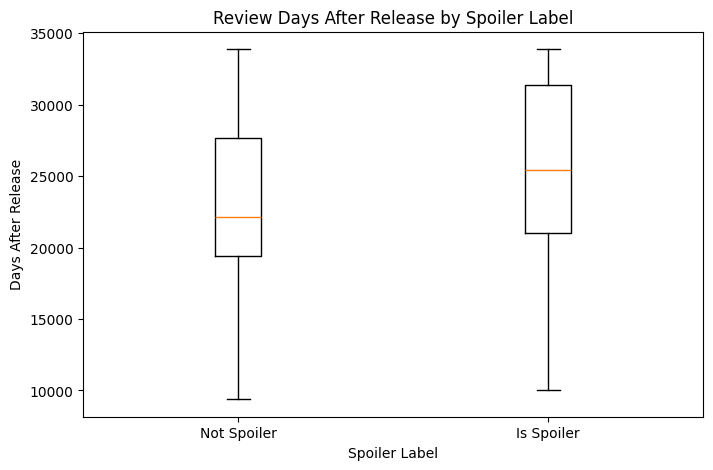

In [19]:


not_spoiler = df_merged[df_merged["is_spoiler"] == 0]["review_days_after_released"].dropna()
is_spoiler = df_merged[df_merged["is_spoiler"] == 1]["review_days_after_released"].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot([not_spoiler, is_spoiler], tick_labels=["Not Spoiler", "Is Spoiler"])
plt.xlabel("Spoiler Label")
plt.ylabel("Days After Release")
plt.title("Review Days After Release by Spoiler Label")
plt.show()

In [20]:
df_merged[df_merged["review_days_after_released"] < 0][
    ["release_date", "review_date", "review_days_after_released"]
].head() #checking who can foresee the future

,release_date,review_date,review_days_after_released


In [21]:
df_merged.dtypes

,0
movie_id,object
plot_summary,object
duration,object
genre,object
movie_rating,float64
release_date,datetime64[ns]
plot_synopsis,object
review_date,datetime64[ns]
user_id,object
is_spoiler,object


In [22]:
df_merged["review_length"]=df_merged["review_text"].astype(str).str.split().str.len()


In [23]:
df_merged[["review_length", "user_rating", "is_spoiler"]].corr()["is_spoiler"] # check correlation for review text length and user rating against is_spolier

,is_spoiler
review_length,0.229988
user_rating,-0.090087
is_spoiler,1.000000


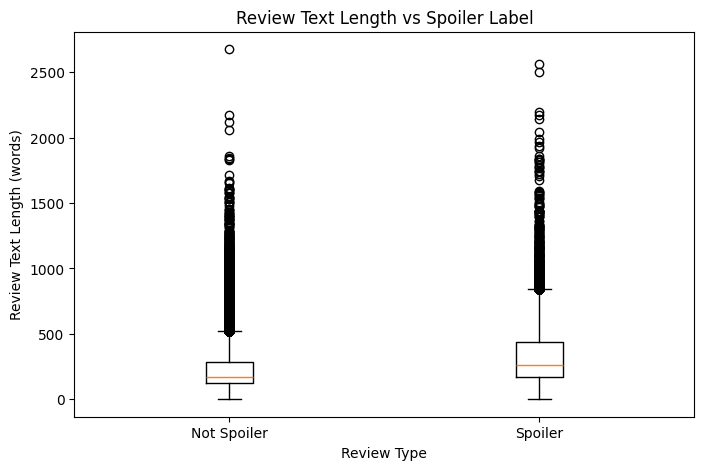

In [24]:
not_spoiler_length = df_merged[df_merged["is_spoiler"] == 0]["review_length"]
spoiler_length = df_merged[df_merged["is_spoiler"] == 1]["review_length"]

plt.figure(figsize=(8, 5))
plt.boxplot([not_spoiler_length, spoiler_length], tick_labels=["Not Spoiler", "Spoiler"])
plt.xlabel("Review Type")
plt.ylabel("Review Text Length (words)")
plt.title("Review Text Length vs Spoiler Label")
plt.show()

Longer the text, more likely to contain spoiler

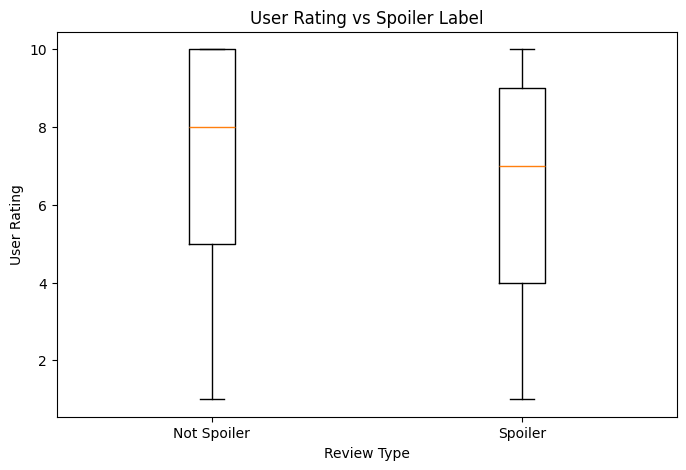

In [25]:
not_spoiler_rating = df_merged[df_merged["is_spoiler"] == 0]["user_rating"]
spoiler_rating = df_merged[df_merged["is_spoiler"] == 1]["user_rating"]

plt.figure(figsize=(8, 5))
plt.boxplot([not_spoiler_rating, spoiler_rating], tick_labels=["Not Spoiler", "Spoiler"])
plt.xlabel("Review Type")
plt.ylabel("User Rating")
plt.title("User Rating vs Spoiler Label")
plt.show()

lower the rating, more likely to be spoiler

In [26]:
df_merged['genre']


,genre
104,"[Adventure, Comedy, Drama]"
105,"[Adventure, Comedy, Drama]"
106,"[Adventure, Comedy, Drama]"
107,"[Adventure, Comedy, Drama]"
108,"[Adventure, Comedy, Drama]"
...,...
573617,"[Drama, Romance]"
573618,"[Drama, Romance]"
573619,"[Drama, Romance]"
573620,"[Drama, Romance]"


In [27]:
df_merged["genre_combo"] = df_merged["genre"].apply(tuple)
genre_summary = df_merged.groupby("genre_combo").agg(
    spoiler_rate=("is_spoiler", "mean")
).sort_values("spoiler_rate", ascending=False)
genre_summary.head(10) #check the genre with most spoiler review

,spoiler_rate
genre_combo,
"(Adventure, Fantasy)",0.452414
"(Adventure, Mystery, Sci-Fi)",0.451613
"(Action, Drama, War)",0.407876
"(Drama, Horror, Sci-Fi)",0.400814
"(Action, Mystery, Sci-Fi)",0.394175
"(Fantasy, Mystery, Thriller)",0.393939
"(Comedy, Horror, Thriller)",0.386628
"(Adventure, Sci-Fi, Thriller)",0.37995
"(Drama, Fantasy, Thriller)",0.379747


## Linear SVM Baseline Model

TF-IDF + LinearSVC for spoiler detection on `review_text`.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)

In [29]:
# Encode labels as integers and extract text feature
y = df_merged['is_spoiler'].astype(int)
X_text = df_merged['review_text'].astype(str)
print('Class distribution:')
print(y.value_counts())

Class distribution:
is_spoiler
0    395717
1    143109
Name: count, dtype: int64


In [30]:
# Stratified 70/15/15 split
X_temp, X_test, y_temp, y_test = train_test_split(
    X_text, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')

Train: 377,178  Val: 80,824  Test: 80,824


In [31]:
# Fit TF-IDF on train only (prevents data leakage)
# ngram_range=(1,2): unigrams + bigrams; sublinear_tf dampens extreme frequencies
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                        sublinear_tf=True, min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)
print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')
print(f'Train matrix shape: {X_train_tfidf.shape}')

Vocabulary size: 50,000
Train matrix shape: (377178, 50000)


In [32]:
# LinearSVC is much faster than SVC(kernel='linear') at 500k rows
# CalibratedClassifierCV wraps it to enable predict_proba for ROC AUC
base_svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model = CalibratedClassifierCV(base_svm, cv=3)
svm_model.fit(X_train_tfidf, y_train)
print('Training complete.')

Training complete.


=== Validation Set ===
              precision    recall  f1-score   support

 Non-Spoiler       0.79      0.96      0.86     59358
     Spoiler       0.71      0.28      0.40     21466

    accuracy                           0.78     80824
   macro avg       0.75      0.62      0.63     80824
weighted avg       0.76      0.78      0.74     80824

ROC AUC: 0.7649104164835488


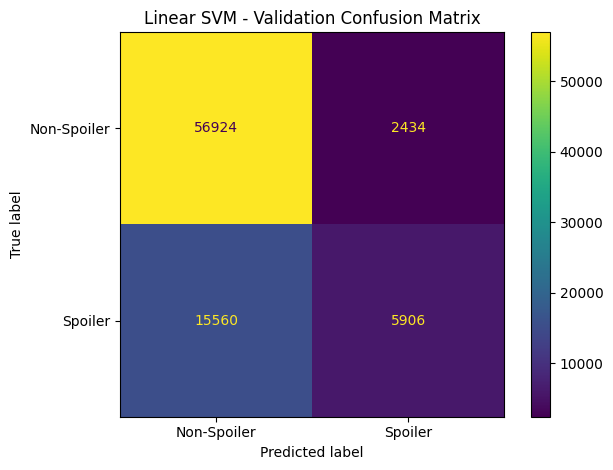

In [33]:
# Evaluate on validation set
y_val_pred  = svm_model.predict(X_val_tfidf)
y_val_proba = svm_model.predict_proba(X_val_tfidf)[:, 1]

print('=== Validation Set ===')
print(classification_report(y_val, y_val_pred, target_names=['Non-Spoiler', 'Spoiler']))
print('ROC AUC:', roc_auc_score(y_val, y_val_proba))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred,
    display_labels=['Non-Spoiler', 'Spoiler'])
plt.title('Linear SVM - Validation Confusion Matrix')
plt.tight_layout()
plt.show()

=== Test Set ===
              precision    recall  f1-score   support

 Non-Spoiler       0.79      0.96      0.86     59358
     Spoiler       0.71      0.27      0.40     21466

    accuracy                           0.78     80824
   macro avg       0.75      0.62      0.63     80824
weighted avg       0.76      0.78      0.74     80824

ROC AUC: 0.760089681069477


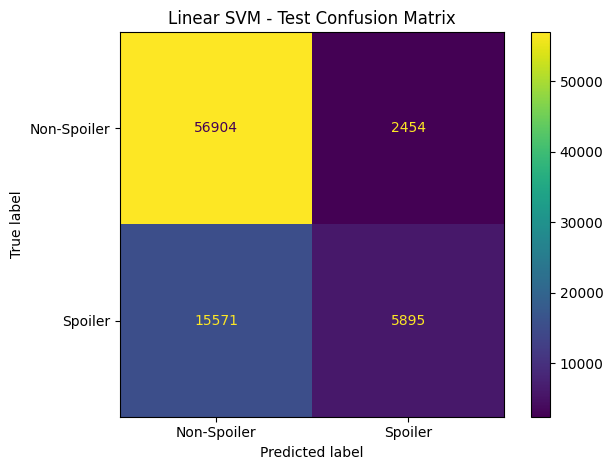

In [34]:
# Final evaluation on held-out test set (run once after validation tuning)
y_test_pred  = svm_model.predict(X_test_tfidf)
y_test_proba = svm_model.predict_proba(X_test_tfidf)[:, 1]

print('=== Test Set ===')
print(classification_report(y_test, y_test_pred, target_names=['Non-Spoiler', 'Spoiler']))
print('ROC AUC:', roc_auc_score(y_test, y_test_proba))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred,
    display_labels=['Non-Spoiler', 'Spoiler'])
plt.title('Linear SVM - Test Confusion Matrix')
plt.tight_layout()
plt.show()

In [35]:
# Qualitative error analysis
fn_mask = (y_test == 1) & (y_test_pred == 0)  # missed spoilers
fp_mask = (y_test == 0) & (y_test_pred == 1)  # incorrectly flagged

fn_examples = X_test[fn_mask].reset_index(drop=True)
fp_examples = X_test[fp_mask].reset_index(drop=True)

print(f'False Negatives (missed spoilers): {fn_mask.sum():,}')
print(f'False Positives (incorrectly flagged): {fp_mask.sum():,}')

print('\n--- False Negatives (sample) ---')
for i, text in enumerate(fn_examples[:5]):
    print(f'[FN {i+1}] {text[:300]}\n')

print('--- False Positives (sample) ---')
for i, text in enumerate(fp_examples[:5]):
    print(f'[FP {i+1}] {text[:300]}\n')

False Negatives (missed spoilers): 15,571
False Positives (incorrectly flagged): 2,454

--- False Negatives (sample) ---
[FN 1] i had little desire to see this film until ppl started telling me that this film was as good or better than seven. After watching this film i now know my friends have very low tastes. This film is not even close to being as great as seven. Brad Pitt, Morgan Freeman, and Kevin Spacey all put on wonde

[FN 2] First review here on imdb. To be honest i took years to see Mamma Mia because i tought oh this is going to be a crap never take a moment in years to see the movie.
It came the right moment i take myself a time to see the whole movie and i was very surprised with this movie. 
Some say it isin´t good 

[FN 3] This movie is simply a masterpiece in every aspect. The first novel written by Chuck Palahniuk, this script was snatched up by 20th Century Fox and green-lit to perfection. There is a brilliance in the writing, especially the narration of one unnamed pro

### Error Analysis Observations

**False Negatives (missed spoilers):**
- Reviews that use vague or euphemistic language (e.g., "the ending surprised me") without naming specific plot events.
- Very short reviews where spoiler content is implied rather than stated.
- Spoilers embedded in otherwise positive praise, making them harder to detect by word frequency alone.

**False Positives (incorrectly flagged):**
- Reviews that discuss genre tropes or general plot structure without revealing specific events.
- Reviews referencing character names or settings that appear in spoiler-heavy vocabulary but in a non-revealing context.
- Highly detailed critical reviews that analyse film craft without disclosing plot outcomes.